In [1]:
import cme.decision_models.diffusion_discrete as dd
import cme.decision_models.quantum_discrete as qd
import jax.numpy as npx
import jax.scipy as sci
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n_states, start_width, mu, sigma, delta = 101,20, npx.asarray([[2]]), npx.asarray([[1]]), 1

In [3]:
q_H = qd._buildH(n_states, mu, sigma).squeeze()
q_init = qd._get_initial_state(n_states, start_width, prob=0.5).squeeze()
q_Mc, q_Mw, q_Mnor = qd._get_measurement_matrix(n_states, start_width, prob=0.25)
q_init

Array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.15617376, 0.15617376, 0.15617376, 0.15617376, 0.15617376,
       0.15617376, 0.15617376, 0.15617376, 0.15617376, 0.15617376,
       0.15617376, 0.15617376, 0.15617376, 0.15617376, 0.15617376,
       0.15617376, 0.15617376, 0.15617376, 0.15617376, 0.15617376,
       0.15617376, 0.15617376, 0.15617376, 0.15617376, 0.15617376,
       0.15617376, 0.15617376, 0.15617376, 0.15617376, 0.15617376,
       0.15617376, 0.15617376, 0.15617376, 0.15617376, 0.15617376,
       0.15617376, 0.15617376, 0.15617376, 0.15617376, 0.15617376,
       0.15617376, 0.        , 0.        , 0.        , 0.     

In [4]:
rt = 20
q_Tr = sci.linalg.expm(-1j * rt * q_H)
q_P = npx.abs(q_Tr @ q_init)**2

In [5]:
Mid = (n_states + 1)//2
mv = npx.arange(-(Mid-1), (Mid))[None,:]
q_Mconf = mv @ q_P
q_Mconf

Array([1.62628104], dtype=float64)

In [6]:
1/7

0.14285714285714285

[-1.         -0.66666667 -0.33333333  0.          0.33333333  0.66666667
  1.        ]
(1, 7) (101,)
1.0
0.9999999999999999
0.9999999999999994
0.9999999999999999
0.9999999999999997
0.9999999999999993
0.9999999999999998
0.9999999999999992
0.9999999999999993
1.0
0.9999999999999997
0.9999999999999998
0.9999999999999996
0.999999999999999
1.0
1.0000000000000013
0.9999999999999972
1.0
1.0000000000000002
0.9999999999999987
0.9999999999999993
1.0000000000000007
0.9999999999999989
0.9999999999999997
0.9999999999999998
0.9999999999999987
0.9999999999999987
0.999999999999999
0.9999999999999993
0.9999999999999996


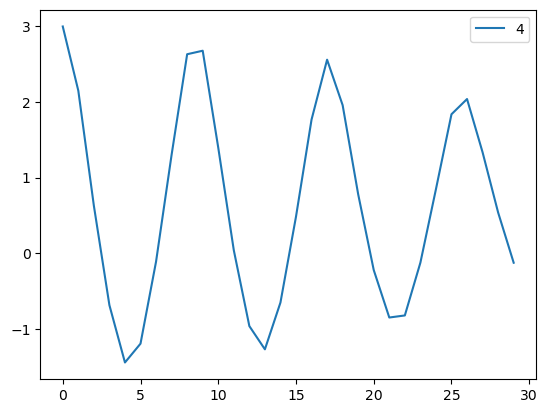

In [7]:
sw = start_width_s = 4
rt=30

conf_arr = []
n_states, start_width, mu, sigma, delta = 7, sw, npx.asarray([[1/3]]), npx.asarray([[1]]), 1
q_H = qd._buildH(n_states, mu, sigma).squeeze()
q_init = qd._get_initial_state(n_states, start_width, prob=1).squeeze()
print(np.diag(q_H))
Mid = (n_states + 1)//2
mv = npx.arange(-(Mid-1), (Mid))[None,:]
print(mv.shape, q_P.shape)
for r in range(rt):
    q_Tr = sci.linalg.expm(-1j * r * q_H)
    q_P = npx.abs(q_Tr @ q_init)**2
    print(q_P.sum())
    q_Mconf = mv @ q_P
    conf_arr.append(q_Mconf)
pd.Series(conf_arr).astype(float).plot(label=sw)
plt.legend()

1.0
1.0000000000000002
1.0000000000000009
0.9999999999999991
1.0000000000000013
0.9999999999999989
0.999999999999999
0.9999999999999976
0.9999999999999994
0.9999999999999989
0.9999999999999979
0.9999999999999991
0.9999999999999989
0.9999999999999991
0.9999999999999958
0.9999999999999976
1.0000000000000004
1.0000000000000013
0.9999999999999988
1.0000000000000009
0.999999999999997
0.9999999999999982
0.9999999999999992
0.9999999999999982
0.9999999999999976
0.9999999999999997
0.9999999999999993
0.9999999999999987
0.9999999999999929
0.9999999999999994
1.0000000000000002
1.0000000000000009
1.0000000000000013
1.0000000000000009
1.0000000000000022
1.0000000000000018
1.0000000000000007
1.0000000000000004
1.0000000000000033
1.000000000000001
1.0000000000000018
1.0000000000000042
1.0000000000000018
1.000000000000001
0.9999999999999967
1.0000000000000004
1.000000000000007
1.0000000000000062
0.9999999999999991
1.0000000000000069
1.0000000000000036
0.9999999999999961
1.0000000000000069
1.00000000000

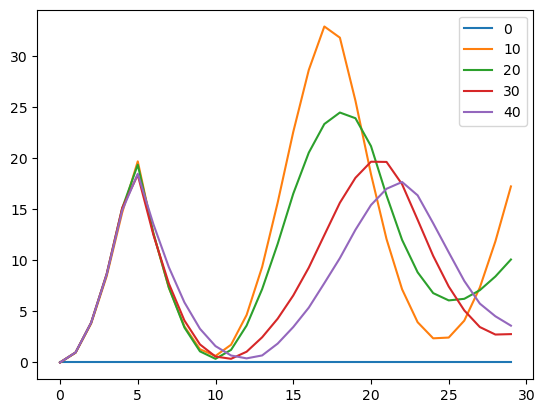

In [11]:
start_width_s = 50
rt=30
t1 = 5
for sw in range(0,start_width_s,10):
    conf_arr = []
    n_states, start_width, mu, mu2, sigma, delta = 101, sw, npx.asarray([[0.100]]), npx.asarray([[0.100]]), npx.asarray([[10]]), 1
    q_H = qd._buildH(n_states, mu, sigma).squeeze()
    q_H2 = qd._buildH(n_states, mu2, sigma).squeeze()
    q_init = qd._get_initial_state(n_states, start_width, prob=0.5).squeeze()
    Mid = (n_states + 1)//2
    mv = npx.arange(-(Mid-1), (Mid))[None,:]
    q_Mc, q_Mw, q_Mnor = qd._get_measurement_matrix(n_states, start_width, prob=0.5)

    for r in range(t1):
        q_Tr = sci.linalg.expm(-1j * r * q_H)
        q_P = npx.abs(q_Tr @ q_init)**2
        print(q_P.sum())
        q_Mconf = mv @ q_P
        conf_arr.append(q_Mconf)
    
    q_Tr1 = sci.linalg.expm(-1j * t1 * q_H)

    for r in range(t1, rt):
        q_Tr2 = sci.linalg.expm(-1j * r * q_H)
        q_P_w = npx.abs(q_Tr2 @ q_Mw @ q_Tr1 @ q_init)**2
        q_P_c = npx.abs(q_Tr2 @ q_Mc @ q_Tr1 @ q_init)**2
        q_P_n = npx.abs(q_Tr2 @ q_Mnor @ q_Tr1 @ q_init)**2
        print((q_P_w + q_P_c + q_P_n).sum())
        q_Mconf = mv @ q_P_n
        conf_arr.append(q_Mconf)
    pd.Series(conf_arr).astype(float).plot(label=sw)
plt.legend()

In [9]:
q_Mw

Array([[0.70710678, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.70710678, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.70710678, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float64)

In [10]:
npx.abs(q_Mnor @ q_Tr1 @ q_init)**2

Array([3.67072061e-05, 9.93371188e-05, 5.20445841e-05, 6.95944550e-05,
       1.47950029e-04, 3.16430390e-05, 3.45867770e-05, 2.41391571e-04,
       4.68462110e-05, 9.29244273e-06, 6.11281100e-05, 1.71467899e-04,
       1.95361323e-04, 9.57478025e-05, 1.84961485e-04, 2.63045068e-04,
       3.00906369e-04, 5.68283010e-05, 3.51143380e-04, 1.10209273e-03,
       4.32597949e-04, 8.05087253e-04, 3.03766580e-04, 3.86776915e-04,
       1.18998915e-03, 9.66059501e-04, 1.28832205e-03, 9.09848098e-04,
       1.22703922e-03, 1.15857233e-03, 1.35187201e-03, 1.23801258e-03,
       1.04157214e-03, 1.78799374e-03, 1.73366217e-03, 2.41025120e-03,
       2.00303467e-03, 1.40085343e-03, 1.46446670e-03, 1.49979788e-03,
       5.69881260e-03, 6.64192066e-03, 9.11936893e-03, 8.06686373e-03,
       8.50148370e-03, 8.60399020e-03, 9.24882219e-03, 1.48201936e-02,
       1.33661954e-02, 1.77361884e-02, 1.69912565e-02, 1.61915679e-02,
       1.86885006e-02, 1.81989455e-02, 1.66063638e-02, 1.66895595e-02,
      